# Feature Engineering | Titanic Dataset

**Content:**

1. Load cleaned data
2. Encoding existing features and creating new features
3. Feature importance and relevance assessment
4. Validate and save engineered features

## 1. Load Cleaned Data

Load the cleaned DataFrames produced by `02_missing_data_handling.ipynb`.

In [78]:
import pandas as pd

train_raw = pd.read_csv("../data/train_cleaned.csv")
test_raw = pd.read_csv("../data/test_cleaned.csv")

print(f"Train: {train_raw.shape}, Test: {test_raw.shape}")
print(f"Train missing: {train_raw.isnull().sum().sum()}, Test missing: {test_raw.isnull().sum().sum()}")
print("\nTrain data:\n")
display(train_raw.head())
print("\nTest data:\n")
display(test_raw.head())

Train: (889, 12), Test: (418, 11)
Train missing: 0, Test missing: 0

Train data:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr



Test data:



,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,Mrs


## 2. Encoding existing features and creating new features

In [ ]:
# Sex: Binary Encoding
train_raw["Sex"] = train_raw["Sex"].map({"male": 0, "female": 1})
test_raw["Sex"] = test_raw["Sex"].map({"male": 0, "female": 1})

# Embarked: One-Hot Encoding (drop_first=True → n-1 columns)
# Encode on concatenated data to guarantee identical columns, then split back.
combined = pd.concat([train_raw, test_raw], keys=["train", "test"])
embarked_dummies = pd.get_dummies(combined["Embarked"], prefix="Embarked", drop_first=True)
combined = pd.concat([combined.drop(columns=["Embarked"]), embarked_dummies], axis=1)
train_raw = combined.loc["train"].reset_index(drop=True)
test_raw = combined.loc["test"].reset_index(drop=True)
# Drop columns that leaked from train during concat (e.g. Survived)
test_raw = test_raw.drop(columns=[c for c in ["Survived"] if c in test_raw.columns])
print(f"\nEmbarked one-hot columns: {[c for c in train_raw.columns if c.startswith('Embarked_')]}")

# FamilySize
# FamilySize captures the total travel group size (self + siblings/spouses + parents/children).
for df in [train_raw, test_raw]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print(f"\nFamilySize range (train): {train_raw['FamilySize'].min()}-{train_raw['FamilySize'].max()}")


# Title: One-Hot Encoding (drop_first=True → n-1 columns)
# Encode on concatenated data to guarantee identical columns.
combined = pd.concat([train_raw, test_raw], keys=["train", "test"])
title_dummies = pd.get_dummies(combined["Title"], prefix="Title", drop_first=True)
combined = pd.concat([combined.drop(columns=["Title"]), title_dummies], axis=1)
train_raw = combined.loc["train"].reset_index(drop=True)
test_raw = combined.loc["test"].reset_index(drop=True)
test_raw = test_raw.drop(columns=[c for c in ["Survived"] if c in test_raw.columns])
print(f"\nTitle one-hot columns: {[c for c in train_raw.columns if c.startswith('Title_')]}")

print(f"\nFinal shapes — Train: {train_raw.shape}, Test: {test_raw.shape}")

print("\nTrain data:\n")
display(train_raw.head())
print("\nTest data:\n")
display(test_raw.head())


Embarked one-hot columns: ['Embarked_Q', 'Embarked_S']

FamilySize range (train): 1-11

Title one-hot columns: ['Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Title_Rev']

Final shapes — Train: (889, 19), Test: (418, 18)

Train data:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,FamilySize,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Title_Rev
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True,2,False,False,True,False,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False,2,False,False,False,True,False,False
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True,1,False,True,False,False,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True,2,False,False,False,True,False,False
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True,1,False,False,True,False,False,False



Test data:



,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,FamilySize,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Title_Rev
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,True,False,1,False,False,True,False,False,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,False,True,2,False,False,False,True,False,False
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,True,False,1,False,False,True,False,False,False
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,False,True,1,False,False,True,False,False,False
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,False,True,3,False,False,False,True,False,False


## 3. Feature Importance and Relevance Assessment

Before running the full pipeline, we assess which features matter most for
predicting survival. This analysis uses six complementary techniques to build
a robust understanding of feature relevance.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from titanic_ml.models import ModelRegistry

%matplotlib inline

SEED = 42

# Build feature matrix and target from the encoded train_raw
# Drop non-feature columns (identifiers, raw text, target)
drop_cols = [c for c in ["PassengerId", "Name", "Ticket", "Survived"] if c in train_raw.columns]
y = train_raw["Survived"].copy()
X = train_raw.drop(columns=drop_cols)

# Train/test split for importance analysis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Features: {list(X.columns)}")
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Title_Rev']
Train: 711 samples, Test: 178 samples


### 3.1 Correlation Analysis

Pearson correlation measures linear association between each feature and Survived.

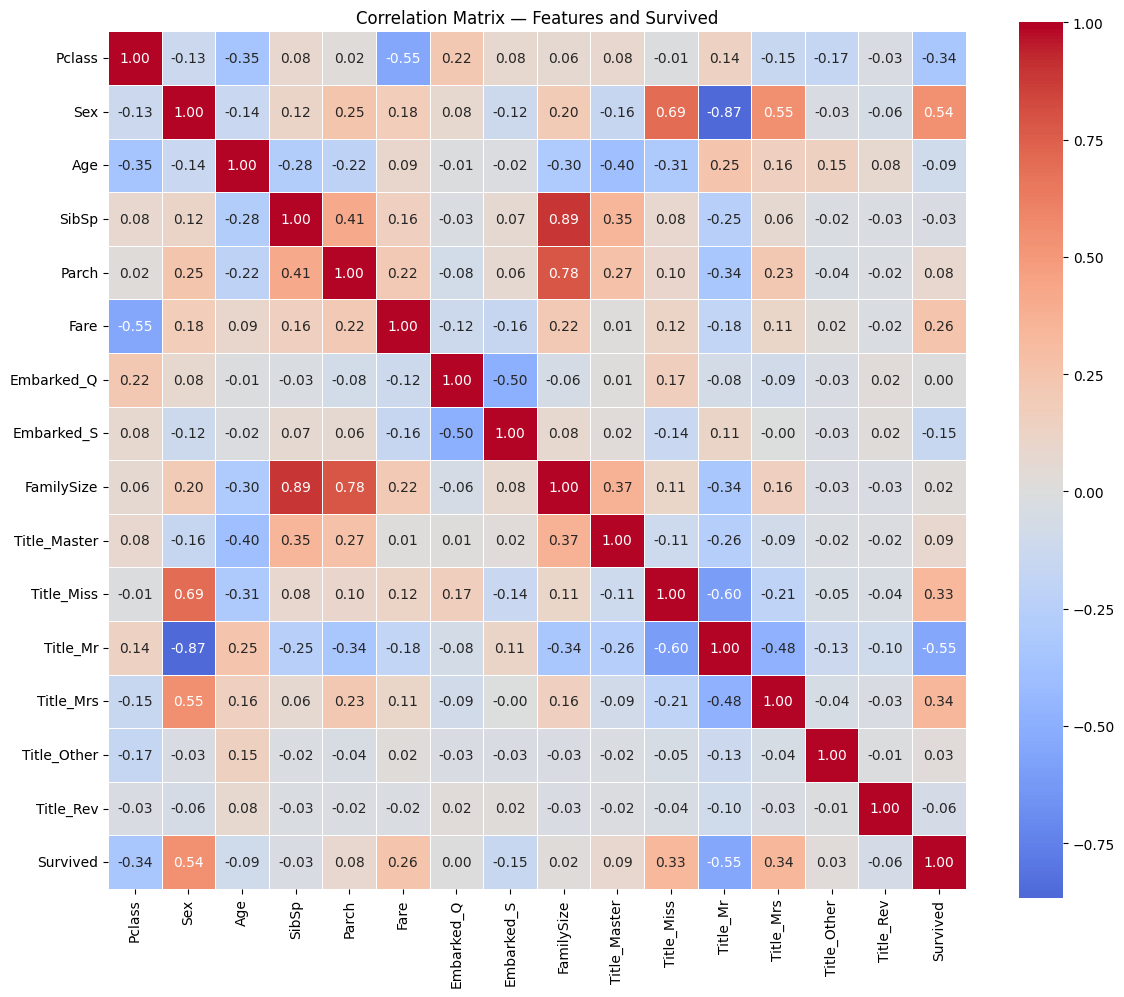

In [81]:
# Build a DataFrame that includes features and the target for correlation
corr_df = X.copy()
corr_df["Survived"] = y.values

# Compute the full correlation matrix
corr_matrix = corr_df.corr()

# Visualize as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix — Features and Survived")
plt.tight_layout()
plt.show()

In [82]:
# Focus on correlations with the target variable
target_corr = corr_matrix["Survived"].drop("Survived").sort_values(ascending=False)
print("Feature correlations with Survived (sorted by strength):")
print(target_corr.to_string())

Feature correlations with Survived (sorted by strength):
Sex             0.541585
Title_Mrs       0.340870
Title_Miss      0.334953
Fare            0.255290
Title_Master    0.085998
Parch           0.083151
Title_Other     0.025799
FamilySize      0.018277
Embarked_Q      0.004536
SibSp          -0.034040
Title_Rev      -0.064871
Age            -0.094634
Embarked_S     -0.151777
Pclass         -0.335549
Title_Mr       -0.547689


Note: 
- `Sex` (+0.54) and `Title_Mr` (−0.55) are the strongest correlates, which is essentially the same signal (adult males had the lowest survival). 
- `Title_Mrs` (+0.34), `Title_Miss` (+0.33), and `Pclass` (−0.34) form a second tier. `Fare` (+0.26) is moderate, likely confounded with `Pclass` (their inter-correlation is −0.55).
- `Age` (−0.09) is surprisingly low, which likely reflects a non-linear effect (children survived at higher rates, but older adults did not).

**Limitation to consider:** Correlation only captures linear relationships. A feature like `Age` may have a non-linear effect (children had higher survival rates) that Pearson correlation underestimates. We need non-linear methods to validate.

### 3.2 Mutual Information

Captures both linear and non-linear dependencies between features and the target.

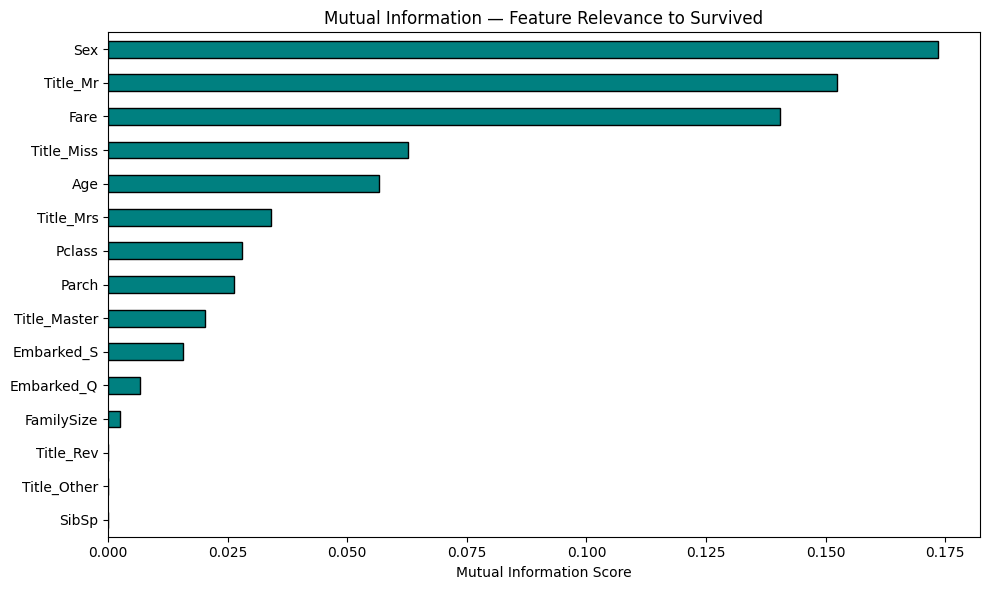

Mutual information scores (descending):
Sex             0.173601
Title_Mr        0.152426
Fare            0.140560
Title_Miss      0.062772
Age             0.056625
Title_Mrs       0.034076
Pclass          0.028019
Parch           0.026384
Title_Master    0.020161
Embarked_S      0.015701
Embarked_Q      0.006654
FamilySize      0.002481
SibSp           0.000000
Title_Other     0.000000
Title_Rev       0.000000


In [83]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information scores between each feature and Survived
mi_scores = mutual_info_classif(X_train, y_train, random_state=SEED)

# Build a Series for easy sorting and plotting
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=True)

# Horizontal bar chart ranked by MI score
plt.figure(figsize=(10, 6))
mi_series.plot(kind="barh", color="teal", edgecolor="black")
plt.xlabel("Mutual Information Score")
plt.title("Mutual Information — Feature Relevance to Survived")
plt.tight_layout()
plt.show()

print("Mutual information scores (descending):")
print(mi_series.sort_values(ascending=False).to_string())

Note:
- `Sex` (0.174), `Title_Mr` (0.152), and `Fare` (0.141) dominate, which is consistent with the correlation. 
- `Age` jumps to 5th place (0.057), up from near-bottom in correlation, confirming a non-linear relationship with survival.
- `SibSp`, `Title_Other`, and `Title_Rev` score exactly zero MI — the estimator could not detect a dependency above its noise floor. For `Title_Other`/`Title_Rev` this is expected (very few samples). For `SibSp`, the weak effect is likely masked by redundancy with `FamilySize`.

**Limitation:** MI doesn't tell us the direction of the relationship (positive or negative), and scores can be noisy on small datasets. It also depends on internal discretization choices for continuous features.

### 3.3 Tree-Based Feature Importance (Gini Importance)

Measures the total reduction in impurity each feature provides across a Random Forest ensemble.

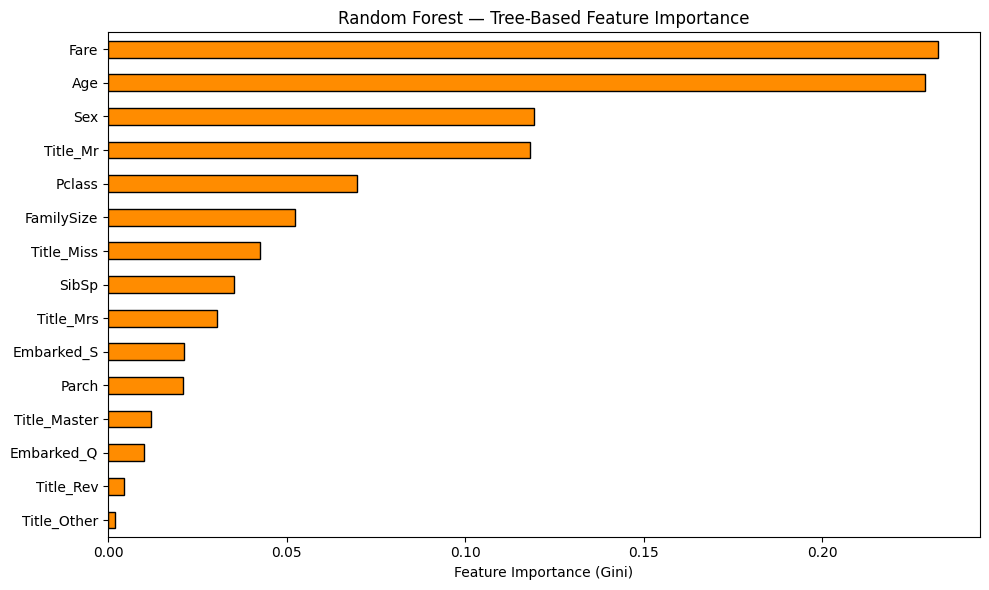

Tree-based feature importances (descending):
Fare            0.232584
Age             0.228760
Sex             0.119317
Title_Mr        0.118048
Pclass          0.069683
FamilySize      0.052349
Title_Miss      0.042619
SibSp           0.035125
Title_Mrs       0.030595
Embarked_S      0.021216
Parch           0.020969
Title_Master    0.012012
Embarked_Q      0.010078
Title_Rev       0.004585
Title_Other     0.002061


In [84]:
# Train a Random Forest using the ModelRegistry
rf_model = ModelRegistry("random_forest")
rf_model.train(X_train, y_train)

# Extract Gini-based feature importances from the underlying sklearn model
importances = rf_model.model.feature_importances_

# Build a Series for sorting and plotting
importance_series = pd.Series(
    importances, index=X_train.columns
).sort_values(ascending=True)

# Horizontal bar chart sorted by importance
plt.figure(figsize=(10, 6))
importance_series.plot(kind="barh", color="darkorange", edgecolor="black")
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest — Tree-Based Feature Importance")
plt.tight_layout()
plt.show()

print("Tree-based feature importances (descending):")
print(importance_series.sort_values(ascending=False).to_string())

Note:
- `Fare` (0.233) and `Age` (0.229) dominate, and `Sex` (0.119) and `Title_Mr` (0.118) drop to 3rd/4th despite being the strongest predictors in correlation and MI. This is a typical case of high-cardinality bias, i.e., that Gini is overweighting continuous features.

**Limitation:** Gini importance is biased toward high-cardinality features. Permutation importance (next) will reveal whether `Fare` and `Age` are genuinely the most important, or if their Gini scores are inflated.

### 3.4 Permutation Importance

Measures how much model accuracy drops when a feature's values are randomly shuffled.

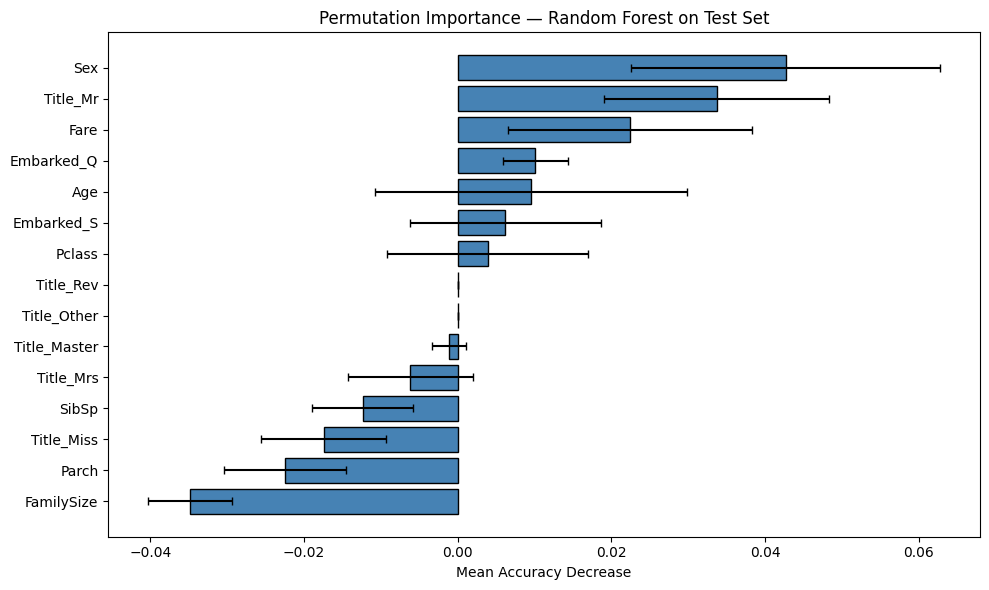

Permutation importance (descending by mean):
     Feature  Importance Mean  Importance Std
         Sex         0.042697        0.020131
    Title_Mr         0.033708        0.014650
        Fare         0.022472        0.015890
  Embarked_Q         0.010112        0.004204
         Age         0.009551        0.020264
  Embarked_S         0.006180        0.012423
      Pclass         0.003933        0.013067
 Title_Other         0.000000        0.000000
   Title_Rev         0.000000        0.000000
Title_Master        -0.001124        0.002247
   Title_Mrs        -0.006180        0.008122
       SibSp        -0.012360        0.006552
  Title_Miss        -0.017416        0.008122
       Parch        -0.022472        0.007945
  FamilySize        -0.034831        0.005504


In [85]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on the test set using the trained Random Forest
perm_result = permutation_importance(
    rf_model.model, X_test, y_test, n_repeats=10, random_state=SEED
)

# Build a DataFrame for easy sorting and plotting
perm_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance Mean": perm_result.importances_mean,
        "Importance Std": perm_result.importances_std,
    }
).sort_values("Importance Mean", ascending=True)

# Horizontal bar chart with error bars
plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["Feature"],
    perm_df["Importance Mean"],
    xerr=perm_df["Importance Std"],
    color="steelblue",
    edgecolor="black",
    capsize=3,
)
plt.xlabel("Mean Accuracy Decrease")
plt.title("Permutation Importance — Random Forest on Test Set")
plt.tight_layout()
plt.show()

print("Permutation importance (descending by mean):")
print(
    perm_df.sort_values("Importance Mean", ascending=False)
    .to_string(index=False)
)

Note:
- `Sex` (0.043) and `Title_Mr` (0.034) reclaim the top spots, confirming the Gini ranking was inflated for `Fare` and `Age`. `Fare` (0.022) drops to 3rd, and `Age` (0.010) drops to 5th with a wide error bar (±0.020), meaning its importance is unstable.
- Several features show negative permutation importance: `FamilySize` (−0.035), `Parch` (−0.022), `Title_Miss` (−0.017), `SibSp` (−0.012). Shuffling these features actually improved accuracy, suggesting the model slightly overfits to noise in them.
- The negative `FamilySize` value is the most pronounced. This could reflect genuine redundancy, or correlation with `SibSp`/`Parch` causing shared importance underestimation.

**Limitation:** Correlated features can share importance. Ex: if `Pclass` and `Fare` are correlated, shuffling one may not hurt much because the other compensates. This can underestimate both.

### 3.5 Recursive Feature Elimination (RFE)

RFECV iteratively removes the least important feature and uses cross-validation to find the optimal subset size.

Optimal number of features: 11
Best cross-validation accuracy: 0.8326


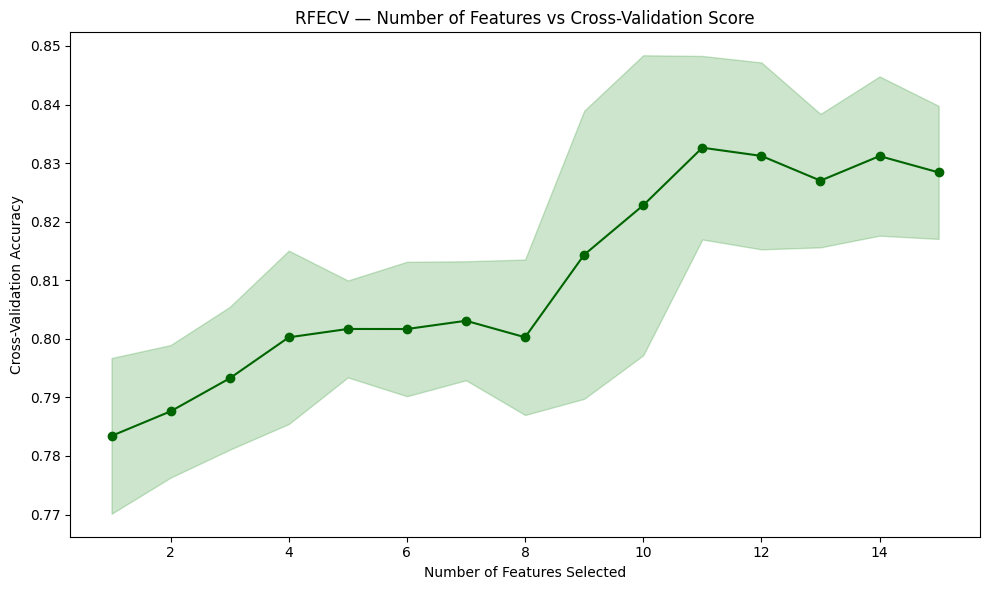


Feature rankings (1 = selected in optimal subset):
     Feature  Ranking  Selected
      Pclass        1      True
         Sex        1      True
       SibSp        1      True
  Embarked_S        1      True
  FamilySize        1      True
Title_Master        1      True
  Title_Miss        1      True
    Title_Mr        1      True
   Title_Mrs        1      True
 Title_Other        1      True
   Title_Rev        1      True
  Embarked_Q        2     False
       Parch        3     False
         Age        4     False
        Fare        5     False


In [86]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Use Logistic Regression as the base estimator for RFE
lr_estimator = LogisticRegression(max_iter=1000, random_state=SEED)

# Run RFECV with 5-fold cross-validation
rfecv = RFECV(
    estimator=lr_estimator,
    cv=5,
    scoring="accuracy",
)
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Best cross-validation accuracy: {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Plot number of features vs cross-validation score
n_features_range = range(1, len(rfecv.cv_results_["mean_test_score"]) + 1)
plt.figure(figsize=(10, 6))
plt.plot(
    n_features_range,
    rfecv.cv_results_["mean_test_score"],
    marker="o",
    color="darkgreen",
)
plt.fill_between(
    n_features_range,
    rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
    rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
    alpha=0.2,
    color="green",
)
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV — Number of Features vs Cross-Validation Score")
plt.tight_layout()
plt.show()

# Display feature ranking table
rfe_ranking_df = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Ranking": rfecv.ranking_,
        "Selected": rfecv.support_,
    }
).sort_values("Ranking")

print("\nFeature rankings (1 = selected in optimal subset):")
print(rfe_ranking_df.to_string(index=False))

Note:
- RFECV selected 11 of 15 features, with accuracy peaking around 83% at 10–11 features. The curve shows a clear jump from ~80% (7 features) to ~83% (10 features), suggesting the title one-hot columns collectively add significant value.

**Limitation:** RFE is greedy (never reconsiders removed features) and estimator-dependent. A different base model could produce a different optimal subset. Results should be cross-referenced with other methods.

### 3.6 SHAP Values

SHAP values quantify each feature's contribution to individual predictions using Shapley values from game theory.

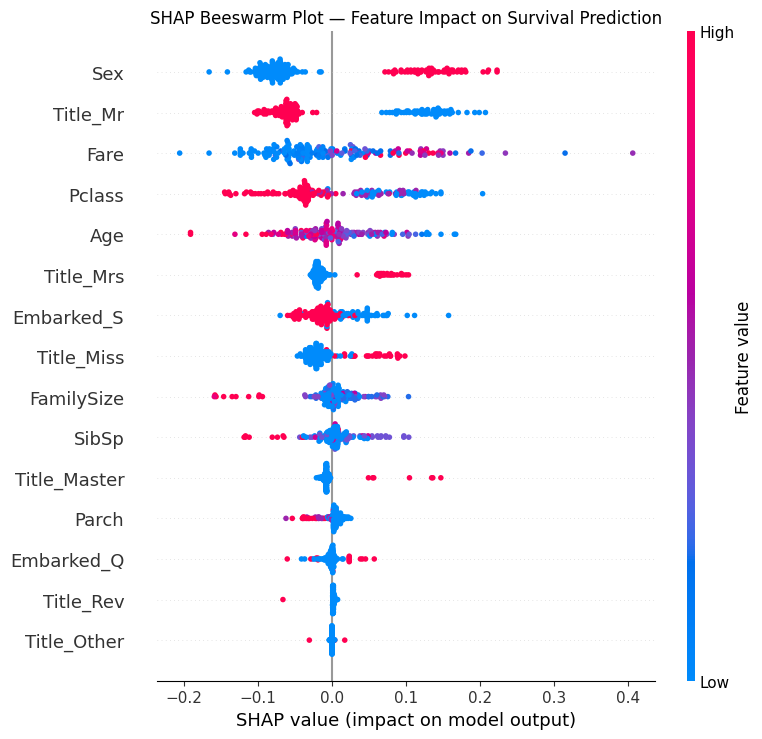

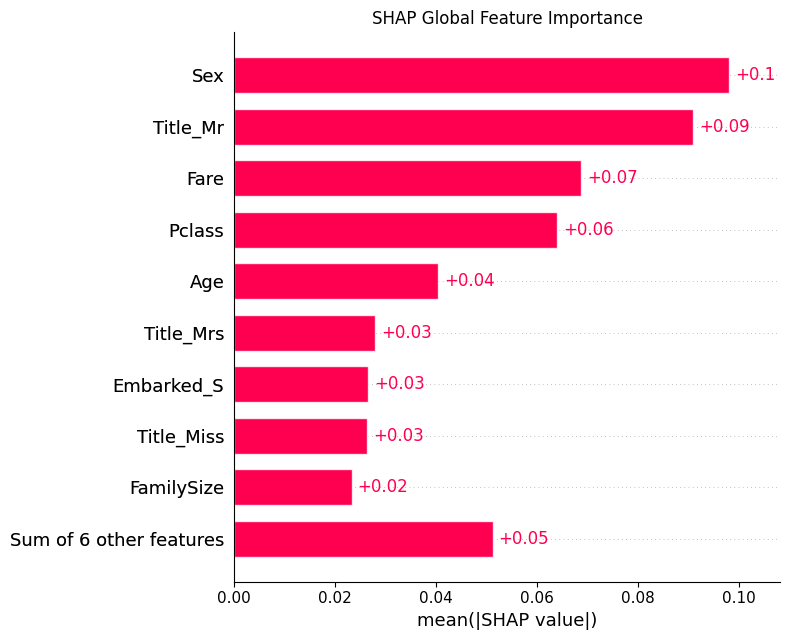

In [87]:
import shap

# Create a TreeExplainer for the trained Random Forest (fast exact algorithm)
explainer = shap.TreeExplainer(rf_model.model)

# Compute SHAP values on the test set
shap_values = explainer(X_test)

# Beeswarm plot — shows SHAP value distribution per feature across all samples
# Each dot is one sample; color indicates feature value (red = high, blue = low)
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title("SHAP Beeswarm Plot — Feature Impact on Survival Prediction")
plt.tight_layout()
plt.show()

# Global importance bar plot — mean absolute SHAP value per feature
shap.plots.bar(shap_values[:, :, 1], show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

Note:
- `Sex` (mean |SHAP| = 0.10) and `Title_Mr` (0.09) are the top two, consistent with every other method. The beeswarm plot shows a clean separation: high `Sex` (female=1, red dots) pushes strongly toward survival, while `Title_Mr`=1 pushes strongly toward non-survival.
- `Fare` (0.07) and `Pclass` (0.06) show wide SHAP distributions, meaning their impact varies significantly across passengers. 
- `Age` (0.04) has a scattered pattern with no clean directional split, confirming the non-linear relationship seen in MI.

**Limitation:** SHAP values are conditional on the model, they explain what the model learned, not necessarily causal relationships. A poorly trained model will produce misleading SHAP values.

### 3.7 Summary Comparison

We have now applied six different feature importance techniques. Let's bring
them all together into a single comparison table to see where they agree and
where they disagree.

In [88]:
# Build a comparison DataFrame ranking features across all techniques
features = X_train.columns.tolist()

# 1. Correlation with Survived (absolute value — higher = more important)
corr_abs = target_corr.abs()

# 2. Mutual information scores
mi_sorted = mi_series.sort_values(ascending=False)

# 3. Tree-based importance
tree_sorted = importance_series.sort_values(ascending=False)

# 4. Permutation importance mean
perm_mean = pd.Series(
    perm_result.importances_mean, index=X_test.columns
)

# 5. RFE ranking (lower ranking = more important, so we invert for consistency)
rfe_ranks = pd.Series(rfecv.ranking_, index=X_train.columns)

# 6. SHAP mean absolute values
shap_importance = pd.Series(
    np.abs(shap_values[:, :, 1].values).mean(axis=0),
    index=X_test.columns,
)

# Convert each to a rank (1 = most important)
comparison = pd.DataFrame({
    "Correlation Rank": corr_abs.rank(ascending=False).astype(int),
    "MI Rank": mi_sorted.rank(ascending=False).astype(int),
    "Tree Importance Rank": tree_sorted.rank(ascending=False).astype(int),
    "Permutation Rank": perm_mean.rank(ascending=False).astype(int),
    "RFE Rank": rfe_ranks.astype(int),
    "SHAP Rank": shap_importance.rank(ascending=False).astype(int),
})

# Compute average rank per feature
comparison["Average Rank"] = comparison.mean(axis=1).round(2)
comparison = comparison.sort_values("Average Rank")

print("Feature Importance Ranking Comparison (1 = most important):")
print(comparison.to_string())

# Note: RFE Rank uses rfecv.ranking_ directly (1=selected, higher=eliminated earlier), 
# while other columns convert raw scores to ranks via .rank(). The scales are directionally consistent (lower=better) but not strictly comparable. 
# RFE ranks reflect elimination order. It is not a continuous importance score. The average rank is a rough consensus indicator, not a precise metric.
print("\nNote: RFE ranks reflect elimination order, not a continuous score.")
print("The average rank is a rough consensus indicator across methods.")

Feature Importance Ranking Comparison (1 = most important):
              Correlation Rank  MI Rank  Tree Importance Rank  Permutation Rank  RFE Rank  SHAP Rank  Average Rank
Sex                          2        1                     3                 1         1          1          1.50
Title_Mr                     1        2                     4                 2         1          2          2.00
Fare                         6        3                     1                 3         5          3          3.50
Pclass                       4        7                     5                 7         1          4          4.67
Age                          8        5                     2                 5         4          5          4.83
Title_Mrs                    3        6                     9                11         1          6          6.00
Title_Miss                   5        4                     7                13         1          8          6.33
Embarked_S          

### 3.8 Key Takeaways

1. **`Sex` and `Title_Mr` are the dominant predictors across all methods.** They represent the same underlying signal (adult males had ~19% survival vs ~74% for females) and consistently rank 1st and 2nd in correlation, MI, permutation importance, and SHAP.

2. **Gini importance is misleading for this dataset.** `Fare` and `Age` appear as the top features in Gini but drop significantly in permutation importance, RFE, and SHAP. This is a clear case of high-cardinality bias, where continuous features get inflated scores simply because they offer more split points.

3. **`Age` has a confirmed non-linear relationship with survival.** It ranks low in correlation (−0.09) but jumps in MI (5th) and SHAP (5th). The beeswarm plot shows a scattered, non-directional pattern, which is consistent with children being prioritized but no simple linear trend.

4. **`FamilySize` shows negative permutation importance (−0.035).** This suggests the model may slightly overfit to it. However, it was retained because SHAP still shows a small positive contribution (0.02), though MI is near-zero (0.002). The negative permutation value may also reflect correlation with `SibSp`/`Parch`.

5. **RFE eliminates `Fare`, `Age`, `Parch`, and `Embarked_Q`** when using Logistic Regression, achieving peak accuracy with 11 features. This reinforces that these features are redundant for linear models, though tree-based models may still benefit from them.

6. **No features were dropped from the final feature set.** Despite some features showing weak or negative importance in individual methods, the consensus across all six methods suggests keeping the full set. The cost of extra features is negligible for tree-based models.

## 4. Validate and Save Engineered Features

Final checks and export for downstream notebooks (model training, submission).

In [89]:
# Drop non-feature columns (same set used in section 3 importance analysis)
drop_cols = [c for c in ["PassengerId", "Name", "Ticket", "Survived"] if c in train_raw.columns]
drop_cols_test = [c for c in ["PassengerId", "Name", "Ticket"] if c in test_raw.columns]

# Keep PassengerId separately for submission
test_passenger_ids = test_raw["PassengerId"].copy() if "PassengerId" in test_raw.columns else None

y_train_full = train_raw["Survived"].copy() if "Survived" in train_raw.columns else None
train_features = train_raw.drop(columns=drop_cols)
test_features = test_raw.drop(columns=drop_cols_test)

# Validate: matching columns
assert list(train_features.columns) == list(test_features.columns), \
    f"Column mismatch!\nTrain: {list(train_features.columns)}\nTest: {list(test_features.columns)}"

# Validate: no missing values
assert train_features.isnull().sum().sum() == 0, \
    f"Train still has missing values:\n{train_features.isnull().sum()[train_features.isnull().sum() > 0]}"
assert test_features.isnull().sum().sum() == 0, \
    f"Test still has missing values:\n{test_features.isnull().sum()[test_features.isnull().sum() > 0]}"

print(f"Train features: {train_features.shape}")
print(f"Test features:  {test_features.shape}")
print(f"Columns: {list(train_features.columns)}")
print(f"\nNo missing values in either set.")

Train features: (889, 15)
Test features:  (418, 15)
Columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Title_Rev']

No missing values in either set.


In [90]:
# Save engineered features for downstream notebooks
train_features.to_csv("../data/train_engineered.csv", index=False)
test_features.to_csv("../data/test_engineered.csv", index=False)

# Save target and passenger IDs separately
if y_train_full is not None:
    y_train_full.to_csv("../data/y_train.csv", index=False, header=True)
if test_passenger_ids is not None:
    test_passenger_ids.to_csv("../data/test_passenger_ids.csv", index=False, header=True)

print(f"Saved train_engineered.csv: {train_features.shape}")
print(f"Saved test_engineered.csv:  {test_features.shape}")

Saved train_engineered.csv: (889, 15)
Saved test_engineered.csv:  (418, 15)
